In [ ]:
!pip install pandas numpy matplotlib seaborn transformers sentence-transformers faiss-cpu PyPDF2 accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 15.7 MB/s eta 0:00:00


In [ ]:
#IMPORT + LOAD DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sample_Zends_synthetic_dataset.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower()

df.head()

,text,service_type,sentiment
0,The Billing speed is amazing.,Billing & Payments,Positive
1,Very satisfied with the Customer Support perfo...,Customer Support,Positive
2,Customer experience with 5G Service is great.,Service Activation,Positive
3,Great experience with the Fiber Broadband.,Broadband Service,Positive
4,Really impressed with the Customer Support.,Customer Support,Positive


In [ ]:
#BASIC DATA CHECK
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 3)

Columns: Index(['text', 'service_type', 'sentiment'], dtype='object')

Missing values:
 text            0
service_type    0
sentiment       0
dtype: int64


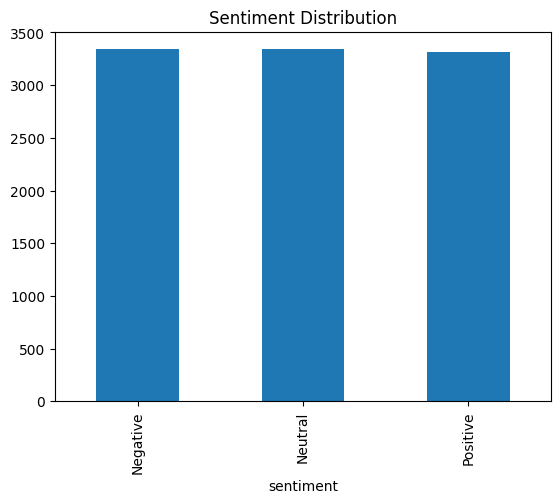

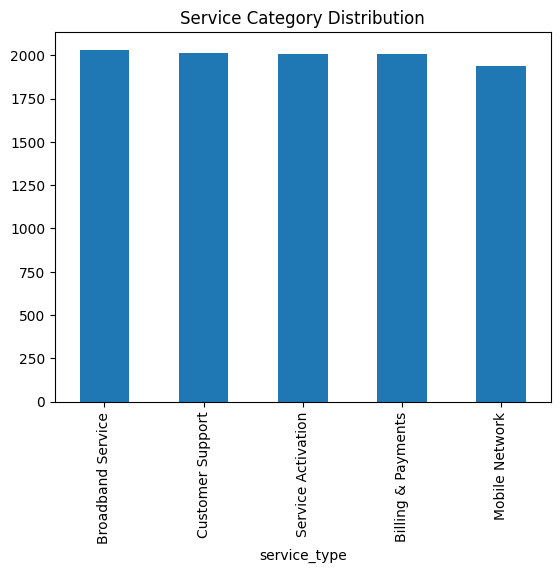

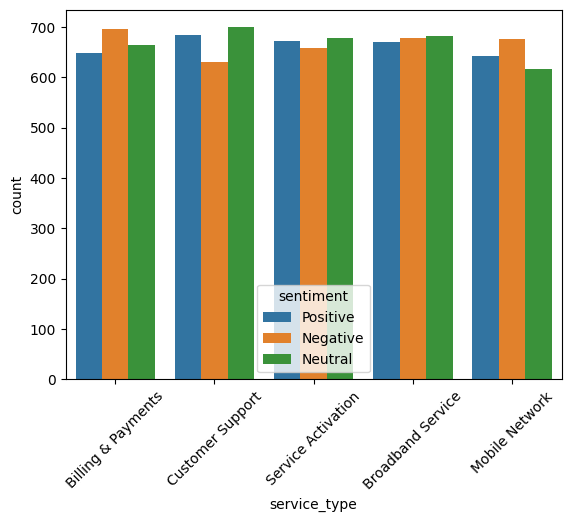

In [ ]:
#EDA

# Sentiment distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

# Service category distribution
df['service_type'].value_counts().plot(kind='bar')
plt.title("Service Category Distribution")
plt.show()

# Sentiment vs category
sns.countplot(data=df, x='service_type', hue='sentiment')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#SENTIMENT MODEL

from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

def get_sentiment(text):
    result = sentiment_model(text)[0]['label']

    if result == "LABEL_2":
        return "Positive"
    elif result == "LABEL_0":
        return "Negative"
    else:
        return "Neutral"

# Test
get_sentiment("Internet is very slow")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

'Negative'

In [ ]:
#TOPIC CLASSIFICATION

def classify_topic(text):
    text = text.lower()

    if any(w in text for w in ["internet","wifi","speed"]):
        return "Broadband Service"
    elif any(w in text for w in ["bill","payment","charge"]):
        return "Billing & Payments"
    elif any(w in text for w in ["network","signal","call"]):
        return "Mobile Network"
    elif "app" in text:
        return "Mobile App Issues"
    elif any(w in text for w in ["activation","sim"]):
        return "Service Activation"
    else:
        return "Customer Support"

# Test
classify_topic("My internet is slow")

'Broadband Service'

In [ ]:
#LOAD PDF

from PyPDF2 import PdfReader

def load_pdf(file):
    reader = PdfReader(file)
    text = ""

    for page in reader.pages:
        content = page.extract_text()
        if content:
            text += content

    return text

kb_text = load_pdf("zends_communications_telecom_knowledge_base.pdf")

len(kb_text)

4614

In [ ]:
#TEXT CHUNKING

def split_text(text, size=300):
    return [text[i:i+size] for i in range(0, len(text), size)]

chunks = split_text(kb_text)

print("Total chunks:", len(chunks))

Total chunks: 16


In [ ]:
#EMBEDDINGS

from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embed_model.encode(chunks, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#FAISS INDEX

import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings))

In [ ]:
#RETRIEVAL FUNCTION

def retrieve(query, k=2):
    q_emb = embed_model.encode([query])
    D, I = index.search(q_emb, k)
    return [chunks[i] for i in I[0]]

In [ ]:
#LLM

from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    max_length=250,
    do_sample=True,
    temperature=0.7
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3F

In [ ]:
#GENERATE RESPONSE

def generate_response(query):
    retrieved_chunks = retrieve(query)
    context = " ".join(retrieved_chunks)[:600]

    prompt = f"""
    You are a professional telecom support assistant.

    Customer Issue:
    {query}

    Relevant Information:
    {context}

    Generate a structured response:
    1. Acknowledge the issue
    2. Explain possible cause
    3. Provide 2-3 steps to fix
    4. Give a polite closing message
    """

    return llm(prompt)[0]['generated_text']

In [ ]:
#TEST FULL PIPELINE

query = "My internet is very slow"

print("Sentiment:", get_sentiment(query))
print("Category:", classify_topic(query))
print("\nResponse:\n", generate_response(query))


Sentiment: Negative
Category: Broadband Service

Response:
 
    You are a professional telecom support assistant.

    Customer Issue:
    My internet is very slow

    Relevant Information:
    . Broadband Service – FAQs & Solutions
ZENDS provides high-speed fiber broadband services including:
 ZENDFiber Home 100 Mbps
 ZENDFiber Home 300 Mbps
 ZENDFiber Home 1 Gbps
Q1: Why is my broadband internet slow?
Possible causes: Network congestion, router issues, or high number of connected devi ces.
Solution: Restart the router and check connected devices.
Q2: My internet is completely down. What should I do?
Possible causes: Fiber cable damage, service outage, or router malfunction.
Solution: Restart modem/router. If the issue continues, report it to support.
6. Billing & Payments – FAQs

    Generate a structured response:
    1. Acknowledge the issue
    2. Explain possible cause
    3. Provide 2-3 steps to fix
    4. Give a polite closing message
    


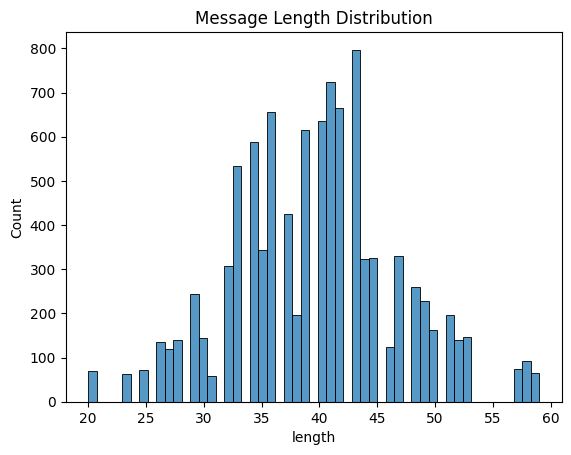

Average message length: 39.6429


In [ ]:
#BUSINESS INSIGHTS
# Message length
df['length'] = df['text'].apply(len)

sns.histplot(df['length'])
plt.title("Message Length Distribution")
plt.show()

# Insight
print("Average message length:", df['length'].mean())

In [ ]:
#FINAL SUMMARY
print("""
Project Summary:
- Sentiment Analysis using Transformer
- Topic Classification using rule-based NLP
- RAG system using FAISS + Sentence Transformers
- AI response generation using LLM

This system helps telecom companies analyze customer feedback automatically.
""")


Project Summary:
- Sentiment Analysis using Transformer
- Topic Classification using rule-based NLP
- RAG system using FAISS + Sentence Transformers
- AI response generation using LLM

This system helps telecom companies analyze customer feedback automatically.



#**Streamlit**

In [ ]:
!pip install -q streamlit pyngrok pandas numpy transformers sentence-transformers faiss-cpu PyPDF2 accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.5 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from PyPDF2 import PdfReader
import faiss
import plotly.express as px

# -------------------------------
# 🔐 LOGIN SYSTEM
# -------------------------------
USERS = {"admin": "1234", "user": "abcd"}

if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

def login():
    st.title("🔐 Login")
    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):
        if username in USERS and USERS[username] == password:
            st.session_state.logged_in = True
        else:
            st.error("Invalid credentials")

if not st.session_state.logged_in:
    login()
    st.stop()

# -------------------------------
# 🎨 UI
# -------------------------------
st.set_page_config(layout="wide")

st.markdown("""
<style>
body {
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
}
</style>
""", unsafe_allow_html=True)

st.markdown("<h1 style='text-align:center;color:#00C9A7;'>📡 ZENDS AI Intelligence System</h1>", unsafe_allow_html=True)

# -------------------------------
# 📊 LOAD DATA (ROBUST)
# -------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("sample_Zends_synthetic_dataset.csv")
    df.columns = df.columns.str.strip().str.lower()
    return df

df = load_data()

# Detect columns dynamically
sentiment_col = [c for c in df.columns if "sentiment" in c][0]
category_col = [c for c in df.columns if "service" in c or "category" in c][0]

# -------------------------------
# 🤖 SENTIMENT MODEL
# -------------------------------
@st.cache_resource
def load_sentiment():
    return pipeline("sentiment-analysis",
                    model="cardiffnlp/twitter-roberta-base-sentiment")

sentiment_model = load_sentiment()

def get_sentiment(text):
    label = sentiment_model(text)[0]['label']
    return {"LABEL_2":"Positive","LABEL_1":"Neutral","LABEL_0":"Negative"}[label]

# -------------------------------
# 🧠 TOPIC CLASSIFICATION
# -------------------------------
def classify_topic(text):
    text = text.lower()
    if "internet" in text:
        return "Broadband Service"
    elif "bill" in text:
        return "Billing & Payments"
    elif "network" in text:
        return "Mobile Network"
    elif "app" in text:
        return "Mobile App Issues"
    elif "sim" in text or "activation" in text:
        return "Service Activation"
    else:
        return "Customer Support"

# -------------------------------
# ⚡ FAST RAG
# -------------------------------
@st.cache_resource
def load_rag():
    reader = PdfReader("zends_communications_telecom_knowledge_base.pdf")
    text = ""
    for p in reader.pages:
        t = p.extract_text()
        if t:
            text += t

    chunks = [text[i:i+300] for i in range(0, len(text), 300)]

    model = SentenceTransformer('all-MiniLM-L6-v2')
    emb = model.encode(chunks)

    index = faiss.IndexFlatL2(emb.shape[1])
    index.add(np.array(emb))

    return model, index, chunks

embed_model, index, chunks = load_rag()

def retrieve(query, k=2):
    q = embed_model.encode([query])
    D, I = index.search(q, k)
    return [chunks[i] for i in I[0]]

# -------------------------------
# 🤖 LLM
# -------------------------------
@st.cache_resource
def load_llm():
    return pipeline("text-generation",
                    model="google/flan-t5-small",
                    max_length=200,
                    do_sample=True,
                    temperature=0.7)

llm = load_llm()

def generate_response(query):
    context = " ".join(retrieve(query))[:500]

    prompt = f"""
    You are a telecom support assistant.

    Customer Issue:
    {query}

    Context:
    {context}

    Provide:
    - A polite acknowledgment
    - Possible cause
    - 2-3 steps solution
    - Closing message
    """

    return llm(prompt)[0]['generated_text']

# -------------------------------
# 💬 CHAT INTERFACE
# -------------------------------
if "chat" not in st.session_state:
    st.session_state.chat = []

user_input = st.chat_input("Enter your issue...")

if user_input:
    sentiment = get_sentiment(user_input)
    category = classify_topic(user_input)
    response = generate_response(user_input)

    full_response = f"""
📊 Sentiment: {sentiment}
📂 Category: {category}

🤖 Response:
{response}
"""

    st.session_state.chat.append(("user", user_input))
    st.session_state.chat.append(("bot", full_response))

for role, msg in st.session_state.chat:
    st.chat_message("user" if role=="user" else "assistant").write(msg)

# -------------------------------
# 📊 DASHBOARD (FULLY FIXED)
# -------------------------------
st.sidebar.title("📊 Analytics Dashboard")

# Sentiment chart
sent_counts = df[sentiment_col].value_counts().reset_index()
sent_counts.columns = ['sentiment', 'count']

sent_fig = px.bar(
    sent_counts,
    x='sentiment',
    y='count',
    color='sentiment',
    title="Sentiment Distribution"
)

# Category chart
cat_fig = px.pie(
    df,
    names=category_col,
    title="Service Categories"
)

st.sidebar.plotly_chart(sent_fig)
st.sidebar.plotly_chart(cat_fig)

Overwriting app.py


In [ ]:
#SET NGROK TOKEN

from pyngrok import ngrok
ngrok.set_auth_token("39FTXeiYaiaRbm41ZYX0li8ULyM_4mbFqnwWZ45Qa1MWeEVcG")

In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
public_url = ngrok.connect(8501)
print("👉 Open this URL:", public_url)

👉 Open this URL: NgrokTunnel: "https://unreverent-herminia-unallusively.ngrok-free.dev" -> "http://localhost:8501"
